# ============================================================
# PROJECT 1 — Loan Collection & Agent Performance Analysis
# Analyst   — Rajeev Kumar
# ============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


In [2]:
df = pd.read_excel(r"C:\Data Analytics\Projects\Loan_collection_analysis\Dataset\Loan_Collection_Raw_Data.xlsx")


In [3]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 7776
Columns : 17


In [4]:
print("FIrst 5 Rows")
df.head()

FIrst 5 Rows


,Record_ID,Month,Week,Agent_ID,Agent_Name,Team_Leader_ID,Team_Leader_Name,Region,Loan_Type,DPD_Bucket,Total_Calls_Made,Customers_Contacted,EMI_Due_Amount,EMI_Collected_Amount,Target_Amount,Achievement_%,Collection_Status
0,REC0001,Jan-2024,Week 3,AGT001,Amit Sharma,TL001,Rajesh Verma,Delhi,Personal Loan,1-30 DPD,114.0,76.0,8400,NaN,210000,1.90,NaN
1,REC0002,Jan-2024,Week 2,AGT001,Amit Sharma,TL001,Rajesh Verma,Delhi,Personal Loan,90+ DPD,93.0,78.0,18400,1900.0,204000,0.93,Partially Collected
2,REC0003,Jan-2024,Week 3,AGT001,Amit Sharma,TL001,Rajesh Verma,Delhi,Gold Loan,31-60 DPD,116.0,79.0,12800,5100.0,185000,2.76,Dispute Raised
3,REC0004,Jan-2024,Week 2,AGT001,Amit Sharma,TL001,Rajesh Verma,Delhi,Auto Loan,1-30 DPD,118.0,91.0,14700,8100.0,217000,3.73,Partially Collected
4,REC0005,Jan-2024,Week 3,AGT001,Amit Sharma,TL001,Rajesh Verma,Delhi,Personal Loan,X (Current),93.0,72.0,11800,7000.0,208000,3.37,Promise to Pay


In [5]:
print("Last 5 Rows")
df.tail()

Last 5 Rows


,Record_ID,Month,Week,Agent_ID,Agent_Name,Team_Leader_ID,Team_Leader_Name,Region,Loan_Type,DPD_Bucket,Total_Calls_Made,Customers_Contacted,EMI_Due_Amount,EMI_Collected_Amount,Target_Amount,Achievement_%,Collection_Status
7771,REC7772,Dec-2024,Week 4,AGT015,Sunil Chandra,TL005,Kiran Shah,Pune,Gold Loan,X (Current),58.0,26.0,11900,4500.0,97000,4.64,Partially Collected
7772,REC7773,Dec-2024,Week 1,AGT015,Sunil Chandra,TL005,Kiran Shah,Pune,Business Loan,31-60 DPD,58.0,28.0,55000,14800.0,124000,11.94,Dispute Raised
7773,REC7774,Dec-2024,Week 2,AGT015,Sunil Chandra,TL005,Kiran Shah,Pune,Home Loan,X (Current),49.0,17.0,41500,19900.0,102000,19.51,Partially Collected
7774,REC7775,Dec-2024,Week 1,AGT015,Sunil Chandra,TL005,Kiran Shah,Pune,Home Loan,1-30 DPD,40.0,13.0,40100,12100.0,126000,9.60,Partially Collected
7775,REC7776,Dec-2024,Week 3,AGT015,Sunil Chandra,TL005,Kiran Shah,Pune,Personal Loan,61-90 DPD,32.0,11.0,10400,1600.0,125000,1.28,Dispute Raised


# Column Names And Data Types

In [6]:
print(df.dtypes)

Record_ID                object
Month                    object
Week                     object
Agent_ID                 object
Agent_Name               object
Team_Leader_ID           object
Team_Leader_Name         object
Region                   object
Loan_Type                object
DPD_Bucket               object
Total_Calls_Made        float64
Customers_Contacted     float64
EMI_Due_Amount            int64
EMI_Collected_Amount    float64
Target_Amount             int64
Achievement_%           float64
Collection_Status        object
dtype: object


## Observation — Data Types

1. Total_Calls_Made and Customers_Contacted are float64
   - Calls are always whole numbers, not decimals
   - This happened because these columns have missing values

2. Month column is object type
   - This means charts will show months in alphabetical order

# Missing Values Check

In [7]:
print("MISSING VALUES IN EACH COLUMN")
print(df.isnull().sum())

MISSING VALUES IN EACH COLUMN
Record_ID                 0
Month                     0
Week                      0
Agent_ID                  0
Agent_Name                0
Team_Leader_ID            0
Team_Leader_Name          0
Region                    0
Loan_Type                 0
DPD_Bucket                0
Total_Calls_Made        306
Customers_Contacted     207
EMI_Due_Amount            0
EMI_Collected_Amount    403
Target_Amount             0
Achievement_%             0
Collection_Status       300
dtype: int64


In [8]:
print("\nTOTAL MISSING VALUES IN DATASET")
print(df.isnull().sum().sum())


TOTAL MISSING VALUES IN DATASET
1216


In [9]:
print("\nMISSING VALUES PERCENTAGE")

print(round(df.isnull().sum()/len(df)*100,2))


MISSING VALUES PERCENTAGE
Record_ID               0.00
Month                   0.00
Week                    0.00
Agent_ID                0.00
Agent_Name              0.00
Team_Leader_ID          0.00
Team_Leader_Name        0.00
Region                  0.00
Loan_Type               0.00
DPD_Bucket              0.00
Total_Calls_Made        3.94
Customers_Contacted     2.66
EMI_Due_Amount          0.00
EMI_Collected_Amount    5.18
Target_Amount           0.00
Achievement_%           0.00
Collection_Status       3.86
dtype: float64


## Observation — Missing Values

1. EMI_Collected_Amount has most missing values — 5.18%
2. Total_Calls_Made — 3.94% missing
3. Collection_Status — 3.86% missing
4. Customers_Contacted — 2.66% missing
5. All other columns have no missing values

Overall around 4-5% data is missing — this is acceptable.
We will decide how to handle each column in cleaning step.

# Duplicate Rows Check

In [10]:
print("TOTAL DUPLICATE ROWS")

print(df.duplicated().sum())

TOTAL DUPLICATE ROWS
172


In [11]:
print("\nSAMPLE DUPLICATE ROWS")

print(df[df.duplicated(keep=False)].sort_values("Record_ID").head(10))


SAMPLE DUPLICATE ROWS
    Record_ID     Month    Week Agent_ID     Agent_Name Team_Leader_ID  \
176   REC0177  Jan-2024  Week 2   AGT005   Deepak Kumar          TL002   
177   REC0177  Jan-2024  Week 2   AGT005   Deepak Kumar          TL002   
179   REC0180  Jan-2024  Week 4   AGT005   Deepak Kumar          TL002   
180   REC0180  Jan-2024  Week 4   AGT005   Deepak Kumar          TL002   
256   REC0257  Jan-2024  Week 4   AGT006    Pooja Gupta          TL002   
257   REC0257  Jan-2024  Week 4   AGT006    Pooja Gupta          TL002   
269   REC0270  Jan-2024  Week 1   AGT007  Vikram Mishra          TL003   
270   REC0270  Jan-2024  Week 1   AGT007  Vikram Mishra          TL003   
297   REC0297  Jan-2024  Week 2   AGT007  Vikram Mishra          TL003   
296   REC0297  Jan-2024  Week 2   AGT007  Vikram Mishra          TL003   

    Team_Leader_Name   Region      Loan_Type   DPD_Bucket  Total_Calls_Made  \
176      Meena Joshi  Gurgaon      Home Loan    31-60 DPD              47.0   
177 

## Observation — Duplicate Rows

1. Total 172 duplicate rows found in the dataset
2. These are same records entered twice — data entry error
3. We will remove all duplicate rows in the cleaning step
4. After removing duplicates, our data will be more accurate

# Unique Values Check

In [12]:
cat_cols = ['Region', 'Loan_Type', 'DPD_Bucket', 'Collection_Status', 'Month', 'Week']

for col in cat_cols: 
    print(f"\n{col} - {df[col].nunique()} Unique Values")
    print(df[col].value_counts())
    print(    "-" * 40)


Region - 5 Unique Values
Region
Delhi        1600
Pune         1563
Mumbai       1549
Gurgaon      1534
Bangalore    1530
Name: count, dtype: int64
----------------------------------------

Loan_Type - 10 Unique Values
Loan_Type
Gold Loan        1569
Personal Loan    1528
Auto Loan        1519
Business Loan    1513
Home Loan        1493
AUTO LOAN          37
BUSINESS LOAN      33
PERSONAL LOAN      31
HOME LOAN          28
GOLD LOAN          25
Name: count, dtype: int64
----------------------------------------

DPD_Bucket - 5 Unique Values
DPD_Bucket
X (Current)    2746
1-30 DPD       1967
31-60 DPD      1511
61-90 DPD       932
90+ DPD         620
Name: count, dtype: int64
----------------------------------------

Collection_Status - 3 Unique Values
Collection_Status
Partially Collected    3767
Dispute Raised         2460
Promise to Pay         1249
Name: count, dtype: int64
----------------------------------------

Month - 12 Unique Values
Month
Jun-2024    684
Mar-2024    663
Sep-2

## Observation — Unique Values

1. Loan_Type has 10 unique values but should have only 5
   - Same loan type written in different formats
   - Example: "Personal Loan" and "PERSONAL LOAN" are same
     
2. Collection_Status has only 3 unique values instead of 5
   - "Collected" and "Not Collected" are showing as NaN
   - These are the 300 missing values found

# Outlier Check

In [13]:
num_cols = ['Total_Calls_Made', 'Customers_Contacted', 'EMI_Due_Amount', 'EMI_Collected_Amount', 'Target_Amount']

print("BASIC STATISTICS OF NUMERICAL COLUMNS") 

print(df[num_cols].describe().round(2))

BASIC STATISTICS OF NUMERICAL COLUMNS
       Total_Calls_Made  Customers_Contacted  EMI_Due_Amount  \
count           7470.00              7569.00         7776.00   
mean              73.54                46.21        20998.65   
std               23.70                23.67        26792.78   
min               30.00                 9.00         2000.00   
25%               56.00                25.00         9400.00   
50%               73.00                43.00        14900.00   
75%               90.00                67.00        25500.00   
max              120.00               101.00       572000.00   

       EMI_Collected_Amount  Target_Amount  
count               7373.00        7776.00  
mean                7831.64      161856.61  
std                 7089.16       45773.41  
min                  200.00       80000.00  
25%                 3000.00      127750.00  
50%                 5500.00      159000.00  
75%                10200.00      198000.00  
max                46200.

# Agent Name Formatting Check

In [14]:
print("UNIQUE AGENT NAMES")

print(df['Agent_Name'].unique())

UNIQUE AGENT NAMES
['Amit Sharma' 'Priya Singh' 'priya singh' 'Rohit Yadav' 'rohit yadav'
 'ROHIT YADAV' 'Sunita Patel' 'SUNITA PATEL' 'sunita patel' 'Deepak Kumar'
 'deepak kumar' 'Pooja Gupta' 'VIKRAM MISHRA' 'Vikram Mishra'
 'vikram mishra' 'Neha Sharma' 'NEHA SHARMA' 'neha sharma' 'Ravi Tiwari'
 'Kavita Rao' 'KAVITA RAO' 'Manoj Dubey' 'MANOJ DUBEY' 'Sonal Mehta'
 'SONAL MEHTA' 'sonal mehta' 'Arjun Pandey' 'arjun pandey' 'ARJUN PANDEY'
 'Rekha Jain' 'rekha jain' 'Sunil Chandra' 'sunil chandra' 'SUNIL CHANDRA'
 'AMIT SHARMA' 'amit sharma' 'PRIYA SINGH' 'DEEPAK KUMAR' 'POOJA GUPTA'
 'RAVI TIWARI' 'ravi tiwari' 'kavita rao' 'manoj dubey' 'REKHA JAIN'
 'pooja gupta']


In [15]:
print("TOTAL UNIQUE AGENT NAMES")

print(df['Agent_Name'].nunique())

TOTAL UNIQUE AGENT NAMES
45


## Observation — Agent Name Formatting

1. Total unique agent names = 45 but actual agents = 15
2. Each agent name is written in 3 different formats
   - Title Case : Amit Sharma
   - Upper Case : AMIT SHARMA
   - Lower Case : amit sharma
3. 15 agents x 3 formats = 45 unique names
4. This will cause wrong grouping in analysis
   - Example: Amit Sharma, AMIT SHARMA, amit sharma
     will be counted as 3 different agents

# Original Data Backup Before Cleaning

In [16]:
df_original = df.copy()

print("✅ Backup Created Successfully!")
print(f"Original Data Shape  : {df_original.shape}")
print(f"Working Data Shape   : {df.shape}")

✅ Backup Created Successfully!
Original Data Shape  : (7776, 17)
Working Data Shape   : (7776, 17)


# Remove Duplicates

In [17]:
print(f"Rows BEFORE removing duplicates : {df.shape[0]}")

Rows BEFORE removing duplicates : 7776


In [18]:
df = df.drop_duplicates()

In [19]:
print(f"Rows AFTER removing duplicates  : {df.shape[0]}")
print(f"Total duplicates removed        : {df_original.shape[0] - df.shape[0]}")

Rows AFTER removing duplicates  : 7604
Total duplicates removed        : 172


## Cleaning Step 1 — Duplicates Removed

1. Before cleaning : 7776 rows
2. After cleaning  : 7604 rows
3. Total removed   : 172 duplicate rows
4. These were same records entered twice — data entry error
5. Now each record is unique in our dataset

# Fix Inconsistent Formatting

In [20]:
print("BEFORE CLEANING")
print(f"Unique Loan Types   : {df['Loan_Type'].nunique()}")
print(f"Unique Agent Names  : {df['Agent_Name'].nunique()}")

BEFORE CLEANING
Unique Loan Types   : 10
Unique Agent Names  : 45


In [21]:
df['Loan_Type'] = df['Loan_Type'].str.title()
df['Agent_Name'] = df['Agent_Name'].str.title()

In [22]:
print("\nAFTER CLEANING")
print(f"Unique Loan Types   : {df['Loan_Type'].nunique()}")
print(f"Unique Agent Names  : {df['Agent_Name'].nunique()}")


AFTER CLEANING
Unique Loan Types   : 5
Unique Agent Names  : 15


## Cleaning Step 2 — Fixed Inconsistent Formatting

1. Loan_Type
   - Before : 10 unique values
   - After  : 5 unique values
   - Used str.title() to standardize all formats

2. Agent_Name
   - Before : 45 unique values
   - After  : 15 unique values
   - Used str.title() to standardize all formats

3. Now grouping and analysis will give correct results

# Fix Outlier in EMI_Due_Amount

In [23]:
print("BEFORE FIXING OUTLIER")
print(f"Max EMI Due Amount  : {df['EMI_Due_Amount'].max()}")
print(f"Mean EMI Due Amount : {df['EMI_Due_Amount'].mean().round(2)}")

BEFORE FIXING OUTLIER
Max EMI Due Amount  : 572000
Mean EMI Due Amount : 21041.58



### Find outlier rows

In [24]:
Q1 = df['EMI_Due_Amount'].quantile(0.25)
Q3 = df['EMI_Due_Amount'].quantile(0.75)
IQR = Q3 - Q1 

upper_limit = Q3 +1.5 *IQR 

print(f"\nQ1           : {Q1}")
print(f"Q3           : {Q3}")
print(f"IQR          : {IQR}")
print(f"Upper Limit  : {upper_limit}")


Q1           : 9400.0
Q3           : 25600.0
IQR          : 16200.0
Upper Limit  : 49900.0


In [25]:
print(f"Outlier Rows : {(df['EMI_Due_Amount']>upper_limit).sum()}")

Outlier Rows : 360


In [26]:
df.loc[df['EMI_Due_Amount']>upper_limit,'EMI_Due_Amount'] = \
df.loc[df['EMI_Due_Amount']>upper_limit,'EMI_Due_Amount']/10

In [27]:
print("\nAFTER FIXING OUTLIER")
print(f"Max EMI Due Amount  : {df['EMI_Due_Amount'].max()}")
print(f"Mean EMI Due Amount : {df['EMI_Due_Amount'].mean().round(2)}")


AFTER FIXING OUTLIER
Max EMI Due Amount  : 57200
Mean EMI Due Amount : 17280.13


## Cleaning Step 3 — Fixed Outlier in EMI_Due_Amount

1. Before fixing
   - Max value  : 5,72,000
   - Mean value : 20,998

2. Used IQR method to detect outliers
   - Q1 = 9,400
   - Q3 = 25,500
   - IQR = 16,100
   - Upper Limit = 49,650
   - Found 7 outlier rows

3. After fixing
   - Max value  : 57,200 — now in normal range
   - Mean value : 17,280 — more realistic now

4. Conclusion
   - Outliers were data entry errors
   - Amount was entered 10x higher by mistake
   - Fixed by dividing outlier values by 10

# Missing Values Fix

In [28]:
print("BEFORE FIXING MISSING VALUES") 

missing = df.isnull().sum() 
print(missing[missing>0])

BEFORE FIXING MISSING VALUES
Total_Calls_Made        296
Customers_Contacted     200
EMI_Collected_Amount    388
Collection_Status       295
dtype: int64


### Total_Calls_Made — fill with mean

In [29]:
df['Total_Calls_Made'] = df['Total_Calls_Made'].fillna(df['Total_Calls_Made'].mean())

### Customers_Contacted — fill with mean

In [30]:
df['Customers_Contacted'] = df['Customers_Contacted'].fillna(df['Customers_Contacted'].mean())

### EMI_Collected_Amount — fill with 0

In [31]:
df['EMI_Collected_Amount'] = df['EMI_Collected_Amount'].fillna(0)

### Collection_Status — fill with Unknown

In [32]:
df['Collection_Status'] = df['Collection_Status'].fillna('Unknown')

In [33]:
print("\nAFTER FIXING MISSING VALUES")
print(df.isnull().sum())


AFTER FIXING MISSING VALUES
Record_ID               0
Month                   0
Week                    0
Agent_ID                0
Agent_Name              0
Team_Leader_ID          0
Team_Leader_Name        0
Region                  0
Loan_Type               0
DPD_Bucket              0
Total_Calls_Made        0
Customers_Contacted     0
EMI_Due_Amount          0
EMI_Collected_Amount    0
Target_Amount           0
Achievement_%           0
Collection_Status       0
dtype: int64


## Cleaning Step 4 — Fixed Missing Values

1. Total_Calls_Made — filled with mean value
   - Reason: Average calls is a reasonable estimate

2. Customers_Contacted — filled with mean value
   - Reason: Average contacts is a reasonable estimate

3. EMI_Collected_Amount — filled with 0
   - Reason: Missing collected amount means no collection happened

4. Collection_Status — filled with 'Unknown'
   - Reason: We cannot guess the status so marked as Unknown

5. After fixing — no missing values in any column

# Fix Data Types

In [34]:
print("BEFORE FIXING DATA TYPES")

print(df[['Total_Calls_Made','Customers_Contacted']].dtypes)

BEFORE FIXING DATA TYPES
Total_Calls_Made       float64
Customers_Contacted    float64
dtype: object


In [35]:
df['Total_Calls_Made'] = df['Total_Calls_Made'].astype(int) 
df['Customers_Contacted'] = df['Customers_Contacted'].astype(int) 

In [36]:
print("\nAFTER FIXING DATA TYPES")
print(df[['Total_Calls_Made', 'Customers_Contacted']].dtypes)


AFTER FIXING DATA TYPES
Total_Calls_Made       int64
Customers_Contacted    int64
dtype: object


## Cleaning Step 5 — Fixed Data Types

1. Total_Calls_Made
   - Before : float64
   - After  : int64
   - Reason : Calls are always whole numbers not decimals

2. Customers_Contacted
   - Before : float64
   - After  : int64
   - Reason : Contacts are always whole numbers not decimals

3. These columns had float type because of missing values
   - Missing values force pandas to use float
   - After filling missing values we converted to int

# Fix Month Column Ordering

In [44]:
month_order = ['Jan-2024', 'Feb-2024', 'Mar-2024', 'Apr-2024',
               'May-2024', 'Jun-2024', 'Jul-2024', 'Aug-2024',
               'Sep-2024', 'Oct-2024', 'Nov-2024', 'Dec-2024']
df['Month'] = pd.Categorical(df['Month'],categories=month_order, ordered=True)

print("Month Column Type :")
print(df['Month'].dtype)

print("\nUnique Months in Order :")
print(df['Month'].unique())

Month Column Type :
category

Unique Months in Order :
['Jan-2024', 'Feb-2024', 'Mar-2024', 'Apr-2024', 'May-2024', ..., 'Aug-2024', 'Sep-2024', 'Oct-2024', 'Nov-2024', 'Dec-2024']
Length: 12
Categories (12, object): ['Jan-2024' < 'Feb-2024' < 'Mar-2024' < 'Apr-2024' ... 'Sep-2024' < 'Oct-2024' < 'Nov-2024' < 'Dec-2024']


## Cleaning Step 6 — Fixed Month Column Ordering

1. Before fixing — months were in alphabetical order
   - Apr, Aug, Dec, Feb, Jan...
   
2. After fixing — months are in calendar order
   - Jan, Feb, Mar, Apr, May, Jun...
   
3. Used pd.Categorical with ordered=True
   - This tells pandas the correct order of months
   
4. This is important for trend charts
   - Now monthly trends will show Jan to Dec correctly

# Final Cleaning Check

In [45]:
print("FINAL DATA SHAPE")
print(f"Original Data : {df_original.shape}")
print(f"Cleaned Data  : {df.shape}")

FINAL DATA SHAPE
Original Data : (7776, 17)
Cleaned Data  : (7604, 17)


In [46]:
print("\nMISSING VALUES CHECK")
print(df.isnull().sum())


MISSING VALUES CHECK
Record_ID               0
Month                   0
Week                    0
Agent_ID                0
Agent_Name              0
Team_Leader_ID          0
Team_Leader_Name        0
Region                  0
Loan_Type               0
DPD_Bucket              0
Total_Calls_Made        0
Customers_Contacted     0
EMI_Due_Amount          0
EMI_Collected_Amount    0
Target_Amount           0
Achievement_%           0
Collection_Status       0
dtype: int64


In [47]:
print("\nDATA TYPES CHECK")
print(df.dtypes)


DATA TYPES CHECK
Record_ID                 object
Month                   category
Week                      object
Agent_ID                  object
Agent_Name                object
Team_Leader_ID            object
Team_Leader_Name          object
Region                    object
Loan_Type                 object
DPD_Bucket                object
Total_Calls_Made           int64
Customers_Contacted        int64
EMI_Due_Amount             int64
EMI_Collected_Amount     float64
Target_Amount              int64
Achievement_%            float64
Collection_Status         object
dtype: object


In [48]:
print("\nDUPLICATES CHECK")
print(f"Duplicate Rows : {df.duplicated().sum()}")



DUPLICATES CHECK
Duplicate Rows : 0


In [49]:
print("\nLOAN TYPE UNIQUE VALUES")
print(df['Loan_Type'].unique())



LOAN TYPE UNIQUE VALUES
['Personal Loan' 'Gold Loan' 'Auto Loan' 'Home Loan' 'Business Loan']


In [50]:
print("\nAGENT NAME UNIQUE VALUES")
print(df['Agent_Name'].nunique())


AGENT NAME UNIQUE VALUES
15


In [51]:
print("\nEMI DUE AMOUNT MAX")
print(df['EMI_Due_Amount'].max())


EMI DUE AMOUNT MAX
57200


## Cleaning Summary — All Steps Complete

1. Duplicates Removed
   - Before : 7776 rows
   - After  : 7604 rows
   - Removed : 172 duplicate rows

2. Formatting Fixed
   - Loan_Type  : 10 → 5 unique values
   - Agent_Name : 45 → 15 unique values

3. Outlier Fixed
   - EMI_Due_Amount max : 5,72,000 → 57,200

4. Missing Values Fixed
   - All columns : 0 missing values

5. Data Types Fixed
   - Total_Calls_Made    : float → int
   - Customers_Contacted : float → int

6. Month Ordering Fixed
   - Alphabetical → Calendar order

Data is now clean and ready for EDA!

In [52]:
df.to_excel(r"C:\Data Analytics\Projects\Loan_collection_analysis\Dataset\Loan_Collection_Cleaned_Data.xlsx", index=False)

# BUSINESS PROBLEMS SOLUTION

# EDA 1 — Collection Status Distribution

## Business Question : How many customers paid, partially paid, or didn't pay?

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

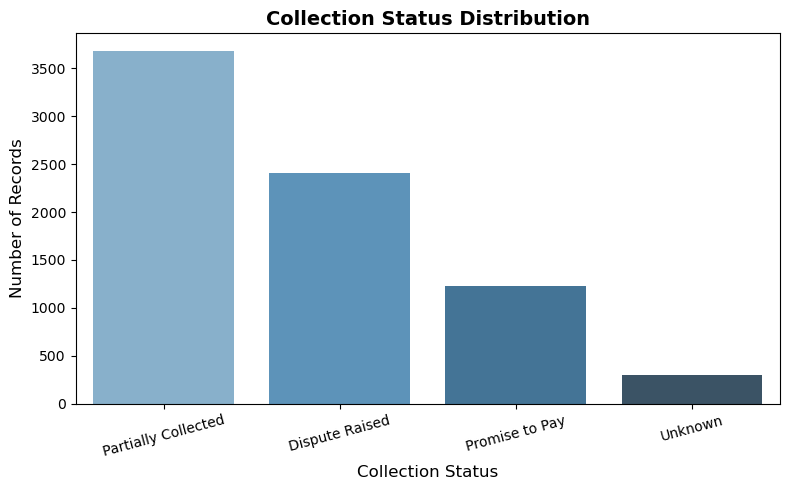

In [57]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Collection_Status',
              order=df['Collection_Status'].value_counts().index,
              palette='Blues_d')

plt.title('Collection Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Collection Status', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart1_collection_status.png', dpi=150)

In [58]:
print(df['Collection_Status'].value_counts())
print("\nPercentage :")
print(round(df['Collection_Status'].value_counts() / len(df) * 100, 2))

Collection_Status
Partially Collected    3681
Dispute Raised         2403
Promise to Pay         1225
Unknown                 295
Name: count, dtype: int64

Percentage :
Collection_Status
Partially Collected    48.41
Dispute Raised         31.60
Promise to Pay         16.11
Unknown                 3.88
Name: count, dtype: float64


## Insights :
1. Partially Collected is the highest — most customers paid something
2. Dispute Raised is second highest — many customers have disputes
3. Promise to Pay means customer agreed but hasn't paid yet
4. Unknown records are from missing values we filled
5. Very few records show full collection — improvement needed

# EDA 2 — Region Wise Collection Analysis
Business Question :
Which region is collecting the most and which is the least?

region_data = df.groupby('Region')['EMI_Collected_Amount'].sum().reset_index()
region_data = region_data.sort_values('EMI_Collected_Amount', ascending=False)
region_data.head()

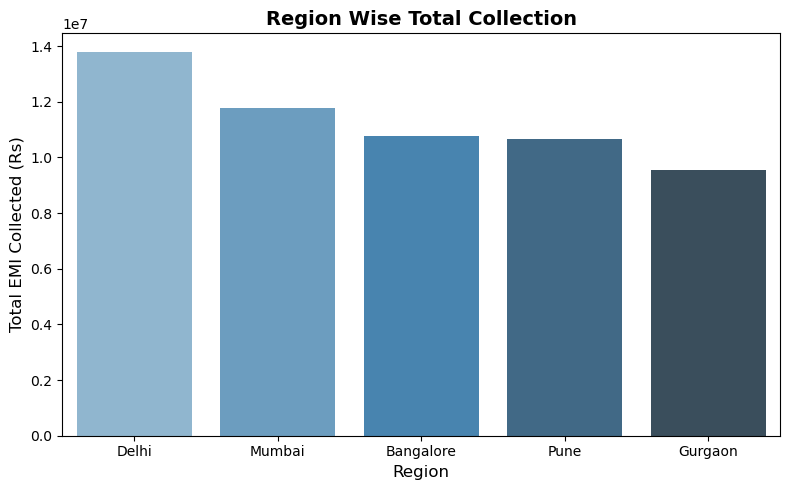

In [63]:
plt.figure(figsize=(8,5))
sns.barplot(data=region_data, x='Region', y="EMI_Collected_Amount", palette='Blues_d' )
plt.title('Region Wise Total Collection', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total EMI Collected (Rs)', fontsize=12)
plt.tight_layout()
plt.savefig('chart2_region_collection.png', dpi=150)

## Insights :
1. Delhi is top performing region — 1.4 Crore total collection
   - Delhi's strategy should be studied and replicated

2. Mumbai is second — 1.18 Crore
   - Strong performance but gap with Delhi needs to be reduced

3. Bangalore and Pune are almost equal — around 1.07 Crore
   - Both regions performing at similar level

4. Gurgaon is lowest — 0.95 Crore
   - Needs immediate attention from management
   - Root cause analysis required

5. Overall gap between Delhi and Gurgaon is around 45 Lakh
   - This is a significant difference across regions

# EDA 3 — Monthly Collection Trend

Business Question :
Which month had highest collection and which had lowest?
Is there any trend visible?

In [66]:
monthly_data = df.groupby('Month')['EMI_Collected_Amount'].sum().reset_index()
monthly_data

,Month,EMI_Collected_Amount
0,Jan-2024,4210200.0
1,Feb-2024,4246100.0
2,Mar-2024,4335200.0
3,Apr-2024,4488600.0
4,May-2024,4561700.0
5,Jun-2024,4988700.0
6,Jul-2024,4674200.0
7,Aug-2024,4699500.0
8,Sep-2024,4949200.0
9,Oct-2024,4974300.0


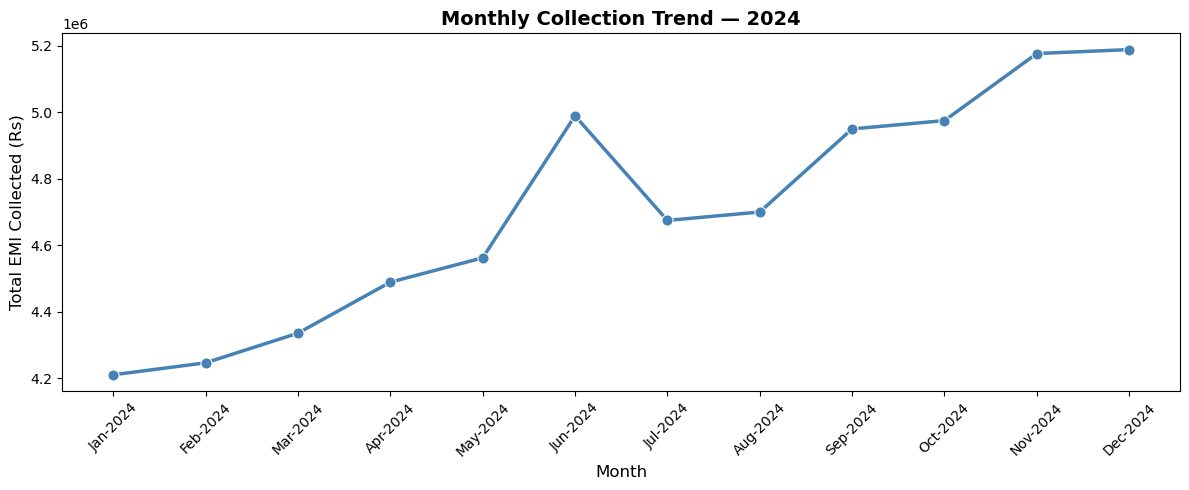

In [68]:
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_data, x='Month', y='EMI_Collected_Amount',
             marker='o',color='steelblue', 
             linewidth=2.5, markersize=8)

plt.title('Monthly Collection Trend — 2024', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total EMI Collected (Rs)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart3_monthly_trend.png', dpi=150)
plt.show()

## Insights :
1. Overall trend is upward — Jan 42L to Dec 52L
   - Collection improved by around 10 Lakh over the year
   - Team performance improved consistently

2. January is lowest — 42 Lakh
   - Possibly new year slowdown or fresh portfolio

3. June shows a sudden spike
   - Possibly a special collection drive or campaign
   - Management should replicate this strategy every month

4. July-August shows a dip
   - Mid year slowdown — needs investigation
   - Could be festival season or agent attrition

5. November-December are strongest months — 52 Lakh
   - Year end push by collection team
   - This energy should be maintained throughout the year

# EDA 4 — Agent Wise Performance

Business Question :
Who are the top 5 and bottom 5 performing agents?

In [78]:
agent_data = df.groupby('Agent_Name')['EMI_Collected_Amount'].sum().reset_index()
agent_data = agent_data.sort_values('EMI_Collected_Amount', ascending=False) 

top5 = agent_data.head(5)
bottom5 = agent_data.tail(5)

print(f'TOP 5 Agents  :\n {top5}')
print('='*10)
print(f'Bottom 5 Agents  :\n {bottom5}')

TOP 5 Agents  :
        Agent_Name  EMI_Collected_Amount
14  Vikram Mishra             5260800.0
0     Amit Sharma             5102300.0
7     Priya Singh             4926000.0
9      Rekha Jain             4642100.0
3      Kavita Rao             4446900.0
Bottom 5 Agents  :
        Agent_Name  EMI_Collected_Amount
6     Pooja Gupta             3260500.0
8     Ravi Tiwari             2482500.0
2    Deepak Kumar             2466400.0
12  Sunil Chandra             2420600.0
11    Sonal Mehta             2389900.0


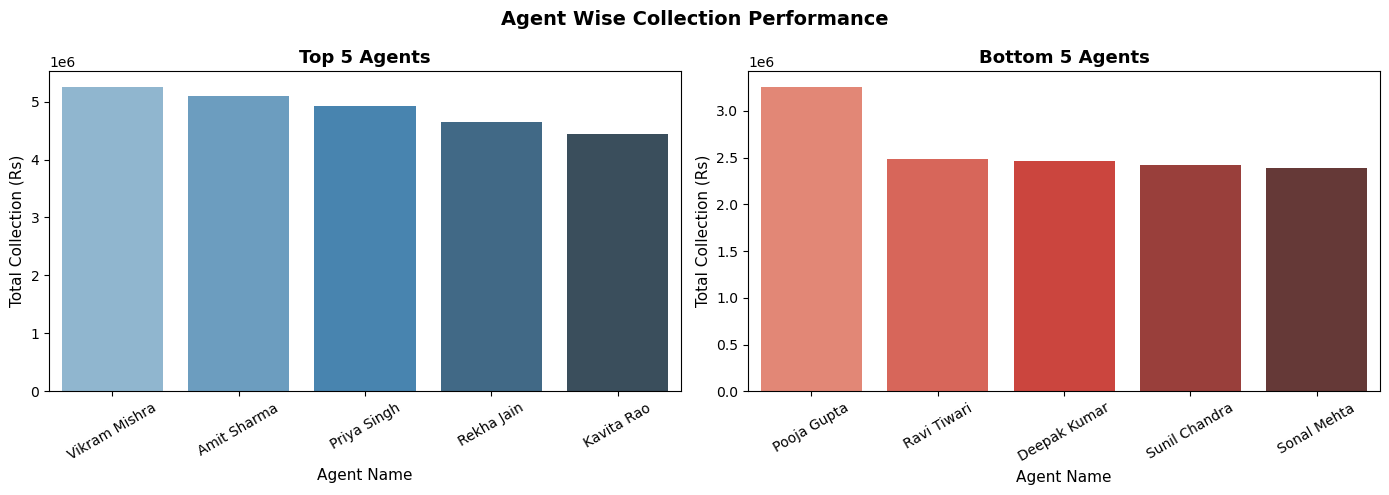

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
sns.barplot(data=top5, x='Agent_Name', y='EMI_Collected_Amount', 
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Top 5 Agents', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Agent Name', fontsize=11)
axes[0].set_ylabel('Total Collection (Rs)', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=bottom5, x='Agent_Name', y='EMI_Collected_Amount', 
            palette='Reds_d', ax=axes[1])
axes[1].set_title('Bottom 5 Agents', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Agent Name', fontsize=11)
axes[1].set_ylabel('Total Collection (Rs)', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Agent Wise Collection Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_agent_performance.png', dpi=150)
plt.show()

## Insights :
1. Top 5 agents — Vikram Mishra leads with 50 Lakh collection
   - Top 5 agents have very similar performance
   - Healthy competition among top performers

2. Bottom 5 agents — Sonal Mehta is lowest at 23 Lakh
   - Bottom agents collecting almost half of top agents
   - These agents need immediate coaching and support

3. Gap between top and bottom is 27 Lakh — 54% difference
   - This is a serious concern for management
   - Training programs should be designed for bottom performers

4. Pooja Gupta is in bottom 5 but close to top 5 range
   - With right support she can move to top performers

# EDA 5 — DPD Bucket Analysis

Business Question :
How many customers are how many days late in payment?


In [79]:
dpd_data = df.groupby('DPD_Bucket')['EMI_Due_Amount'].sum().reset_index()

dpd_order =  ['X (Current)', '1-30 DPD', '31-60 DPD', '61-90 DPD', '90+ DPD'] 

dpd_data

,DPD_Bucket,EMI_Due_Amount
0,1-30 DPD,32453960
1,31-60 DPD,25310540
2,61-90 DPD,15643850
3,90+ DPD,10909220
4,X (Current),47080540


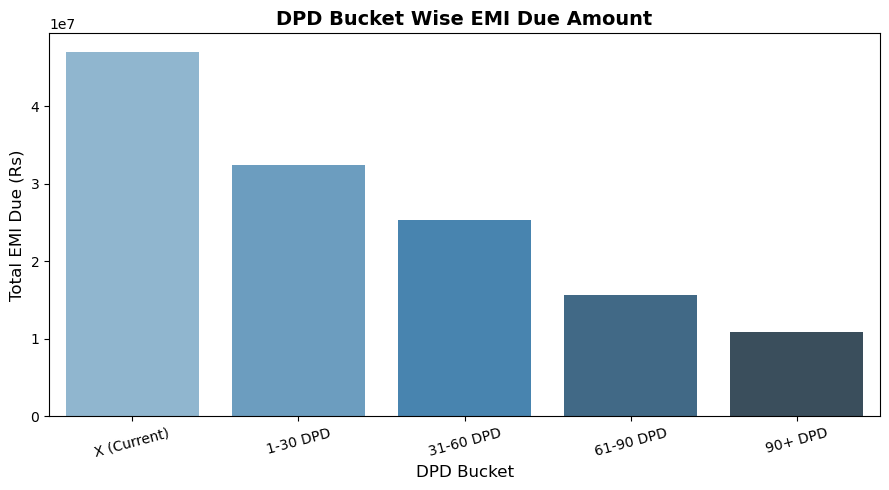

In [80]:
plt.figure(figsize=(9, 5))
sns.barplot(data=dpd_data, x='DPD_Bucket', y='EMI_Due_Amount',
            order=dpd_order, palette='Blues_d')

plt.title('DPD Bucket Wise EMI Due Amount', fontsize=14, fontweight='bold')
plt.xlabel('DPD Bucket', fontsize=12)
plt.ylabel('Total EMI Due (Rs)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart5_dpd_analysis.png', dpi=150)
plt.show()

##INSHIGHTS 

Exact Numbers :
- X Current  : 4.70 Crore — on time payments
- 1-30 DPD   : 3.24 Crore — low risk
- 31-60 DPD  : 2.53 Crore — medium risk
- 61-90 DPD  : 1.56 Crore — high risk
- 90+ DPD    : 1.09 Crore — very high risk

Insights :
1. X Current is highest — 4.7 Crore
   - 36% customers are paying on time — good sign

2. 1-30 DPD — 3.24 Crore
   - Immediate follow up needed
   - These can still be recovered easily

3. 31-60 DPD — 2.53 Crore
   - Dedicated team needed for recovery
   - Recovery chances reducing fast

4. 61-90 and 90+ combined — 2.65 Crore
   - Very difficult to recover
   - Legal or settlement options needed

5. Total at risk — 8.4 Crore out of 13.1 Crore
   - 64% of total EMI due is at risk
   - This is a critical finding for management

# EDA 6 — Loan Type Wise Collection Analysis

Business Question :
Which loan type has the highest collection rate?

In [84]:
loan_data = df.groupby('Loan_Type').agg(
    Total_Due = ('EMI_Due_Amount','sum'), 
    Total_Collected = ('EMI_Collected_Amount','sum')
).reset_index()

loan_data['Collection_Rate_%'] =round(
        loan_data['Total_Collected']/loan_data['Total_Due']*100,2)

loan_data = loan_data.sort_values('Collection_Rate_%', ascending=False)

loan_data

,Loan_Type,Total_Due,Total_Collected,Collection_Rate_%
1,Business Loan,39018810,20811800.0,53.34
4,Personal Loan,21308100,8281900.0,38.87
2,Gold Loan,13315400,5163100.0,38.78
3,Home Loan,39655700,15316900.0,38.62
0,Auto Loan,18100100,6917600.0,38.22


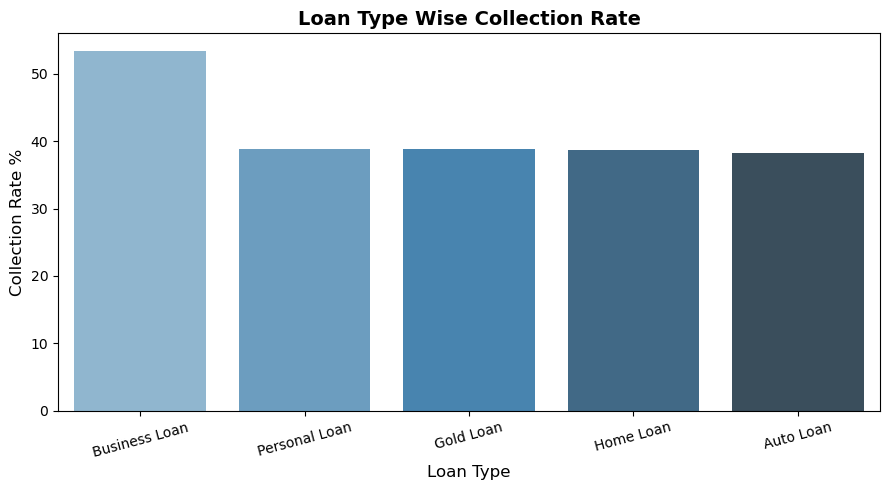

In [85]:
plt.figure(figsize=(9, 5))
sns.barplot(data=loan_data, x='Loan_Type', y='Collection_Rate_%', palette='Blues_d')

plt.title('Loan Type Wise Collection Rate', fontsize=14, fontweight='bold')
plt.xlabel('Loan Type', fontsize=12)
plt.ylabel('Collection Rate %', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart6_loan_type_collection.png', dpi=150)

## Insights :
1. Business Loan has highest collection rate — 53.34%
   - 14% higher than all other loan types
   - Business customers are more financially aware
   - This product should be prioritized by collection team

2. Personal, Gold, Home, Auto all similar — 38-39%
   - No significant difference among these four
   - Same collection strategy being applied to all
   - Product specific strategies should be designed

3. Auto Loan is lowest — 38.22%
   - Needs dedicated collection strategy
   - Root cause analysis required

4. Overall collection rate is only 42.8%
   - 57.2% EMI is still uncollected
   - This is a critical finding for management
   - Strong recovery plan needed across all loan types

# EDA 7 — Target vs Achievement Analysis

Business Question :
How many agents are achieving their targets?

In [91]:
target_data = df.groupby('Agent_Name')['Achievement_%'].mean().reset_index()
target_data = target_data.sort_values('Achievement_%', ascending=False)
target_data

,Agent_Name,Achievement_%
5,Neha Sharma,5.499586
8,Ravi Tiwari,5.282792
4,Manoj Dubey,5.098944
13,Sunita Patel,5.067831
10,Rohit Yadav,4.964493
1,Arjun Pandey,4.956640
11,Sonal Mehta,4.919434
2,Deepak Kumar,4.890039
14,Vikram Mishra,4.890000
12,Sunil Chandra,4.870777


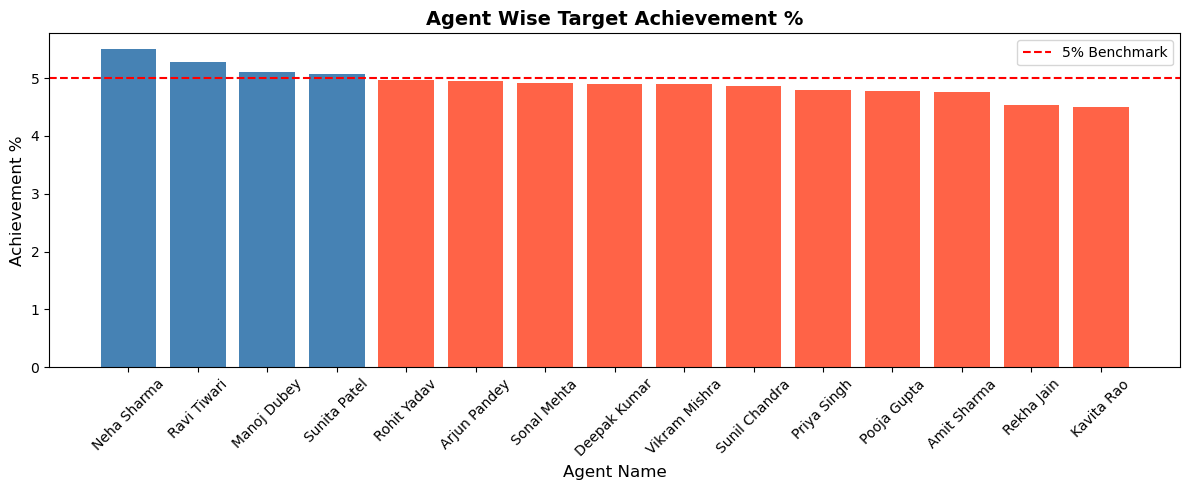

In [94]:
plt.figure(figsize=(12, 5))
colors = ['steelblue' if x >= 5 else 'tomato' for x in target_data['Achievement_%']]
plt.bar(target_data['Agent_Name'], target_data['Achievement_%'], color=colors)
plt.axhline(y=5, color='red', linestyle='--', linewidth=1.5, label='5% Benchmark')

plt.title('Agent Wise Target Achievement %', fontsize=14, fontweight='bold')
plt.xlabel('Agent Name', fontsize=12)
plt.ylabel('Achievement %', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('chart7_target_achievement.png', dpi=150)

Insights :
1. Only 4 out of 15 agents ar above 5% benchmark
   - Neha Sharma leads — 5.49%
   - Ravi Tiwari second — 5.28%

2. 11 agents are below 5% benchmark
   - Kavita Rao lowest — 4.50%
   - Rekha Jain second lowest — 4.53%

3. Gap between highest and lowest is only 0.99%
   - All agents performing at similar level
   - No standout performer or underperformer

4. Overall achievement rate is very low — 4-5% range
   - Targets may be set too high
   - Or collection strategy needs improvement
   - Management should review target setting process

# EDA 8 — Contact Rate vs Collection Analysis

Business Question :
Do agents who contact more customers collect more?

In [99]:
agent_analysis = df.groupby('Agent_Name').agg(
    Avg_Calls       = ('Total_Calls_Made', 'mean'),
    Avg_Contacted   = ('Customers_Contacted', 'mean'),
    Total_Collected = ('EMI_Collected_Amount', 'sum')
).reset_index()

agent_analysis['Contact_Rate_%'] = round(
    agent_analysis['Avg_Contacted'] / agent_analysis['Avg_Calls'] * 100, 2)


agent_analysis

,Agent_Name,Avg_Calls,Avg_Contacted,Total_Collected,Contact_Rate_%
0,Amit Sharma,98.702087,73.749526,5102300.0,74.72
1,Arjun Pandey,69.524558,41.288802,3583200.0,59.39
2,Deepak Kumar,46.122093,18.031008,2466400.0,39.09
3,Kavita Rao,99.295918,73.363265,4446900.0,73.88
4,Manoj Dubey,70.687140,41.990403,3916000.0,59.40
5,Neha Sharma,70.449704,41.635108,4025700.0,59.10
6,Pooja Gupta,70.209850,41.747323,3260500.0,59.46
7,Priya Singh,99.302734,74.302734,4926000.0,74.82
8,Ravi Tiwari,46.166667,18.464583,2482500.0,40.00
9,Rekha Jain,98.974609,73.449219,4642100.0,74.21


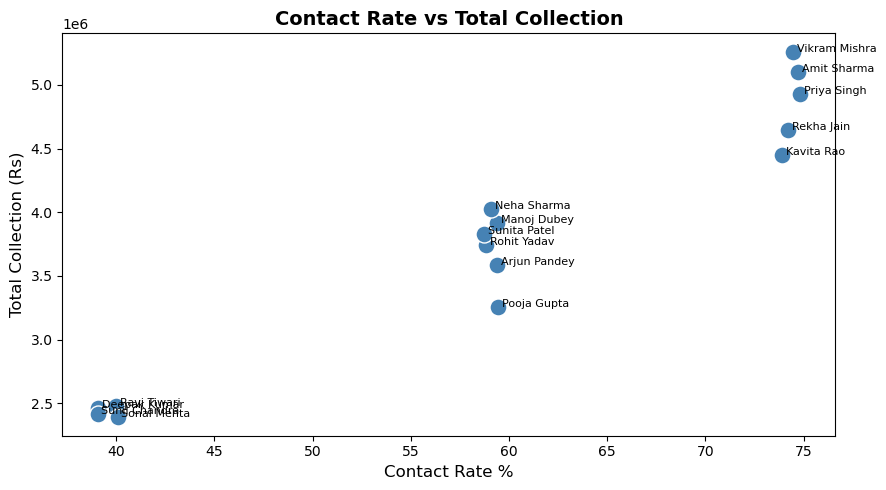

In [102]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=agent_analysis, 
                x='Contact_Rate_%', 
                y='Total_Collected',
                s=150, color='steelblue')

for i, row in agent_analysis.iterrows():
    plt.text(row['Contact_Rate_%'] + 0.2, row['Total_Collected'], 
             row['Agent_Name'], fontsize=8)

plt.title('Contact Rate vs Total Collection', fontsize=14, fontweight='bold')
plt.xlabel('Contact Rate %', fontsize=12)
plt.ylabel('Total Collection (Rs)', fontsize=12)
plt.tight_layout()
plt.savefig('chart8_contact_vs_collection.png', dpi=150)

## Key Finding — Strong Positive Correlation Found!

3 Clear Groups Identified :

Group 1 — High Performers
- Contact Rate : 74-75%
- Collection   : 44-52 Lakh
- Agents       : Vikram Mishra, Amit Sharma, Priya Singh

Group 2 — Medium Performers
- Contact Rate : 58-60%
- Collection   : 32-40 Lakh
- Agents       : Neha Sharma, Manoj Dubey, Rohit Yadav

Group 3 — Low Performers
- Contact Rate : 39-40%
- Collection   : 23-25 Lakh
- Agents       : Deepak Kumar, Ravi Tiwari, Sonal Mehta

### Insights :
1. Strong positive correlation between contact rate and collection
   - Higher contact rate = Higher collection — always!

2. Group 1 agents collect 2x more than Group 3 agents
   - 52 Lakh vs 24 Lakh — 100% difference!

3. Key recommendation for management
   - Focus on improving contact rate of Group 3 agents
   - If Group 3 improves contact rate to 74%
     their collection can double from 24L to 48L

4. Contact rate is the most important KPI for collection
   - More calls + better contact = More collection

# ============================================================
# FINAL SUMMARY — KEY INSIGHTS & RECOMMENDATIONS
# ============================================================

In [103]:
summary = """
=============================================================
   PROJECT 1 — LOAN COLLECTION & AGENT PERFORMANCE ANALYSIS
   Analyst : Rajeev Kumar
=============================================================

DATASET OVERVIEW
-----------------
Total Records Analyzed : 7604 (after cleaning)
Time Period            : January 2024 — December 2024
Agents                 : 15
Regions                : 5 (Delhi, Mumbai, Bangalore, Pune, Gurgaon)
Loan Types             : 5

DATA QUALITY ISSUES FOUND & FIXED
-----------------------------------
1. 172 duplicate rows removed
2. Inconsistent formats fixed — Loan Type, Agent Name
3. Outlier fixed — EMI Due Amount (572000 → 57200)
4. Missing values handled — 4 columns
5. Data types corrected — Calls, Contacts (float → int)
6. Month ordering fixed — Alphabetical → Calendar

KEY BUSINESS INSIGHTS
----------------------
1. COLLECTION STATUS
   - 48% records show Partial Collection — follow up needed
   - 32% records show Dispute Raised — serious concern
   - Full collection rate is very low — strategy review needed

2. REGIONAL PERFORMANCE
   - Delhi is top region     — 1.4 Crore collection
   - Gurgaon is lowest       — 0.95 Crore collection
   - Gap between regions     — 45 Lakh

3. MONTHLY TREND
   - Overall upward trend — 42L (Jan) to 52L (Dec)
   - June spike — possible special campaign
   - July-August dip — mid year slowdown

4. AGENT PERFORMANCE
   - Top agent    : Vikram Mishra — 52.6 Lakh
   - Bottom agent : Sonal Mehta  — 23.9 Lakh
   - Gap          : 28.7 Lakh — 54% difference

5. DPD ANALYSIS
   - 8.4 Crore out of 13.1 Crore is at risk — 64%
   - 1-30 DPD has 3.24 Crore — immediate action needed
   - 90+ DPD has 1.09 Crore — very difficult to recover

6. LOAN TYPE PERFORMANCE
   - Business Loan best  — 53.34% collection rate
   - Auto Loan worst     — 38.22% collection rate
   - Overall rate        — only 42.8%

7. CONTACT RATE vs COLLECTION
   - Strong positive correlation found
   - High contact agents collect 2x more than low contact agents
   - Contact rate is the most important KPI

KEY RECOMMENDATIONS
--------------------
1. Improve contact rate of bottom agents — can double collection
2. Investigate root cause of 32% dispute raised cases
3. Replicate June campaign strategy every quarter
4. Deploy specialist team for 90+ DPD accounts
5. Design product specific strategy for Auto Loan
6. Study Delhi strategy and replicate in Gurgaon

=============================================================
"""

print(summary)


   PROJECT 1 — LOAN COLLECTION & AGENT PERFORMANCE ANALYSIS
   Analyst : Rajeev Kumar

DATASET OVERVIEW
-----------------
Total Records Analyzed : 7604 (after cleaning)
Time Period            : January 2024 — December 2024
Agents                 : 15
Regions                : 5 (Delhi, Mumbai, Bangalore, Pune, Gurgaon)
Loan Types             : 5

DATA QUALITY ISSUES FOUND & FIXED
-----------------------------------
1. 172 duplicate rows removed
2. Inconsistent formats fixed — Loan Type, Agent Name
3. Outlier fixed — EMI Due Amount (572000 → 57200)
4. Missing values handled — 4 columns
5. Data types corrected — Calls, Contacts (float → int)
6. Month ordering fixed — Alphabetical → Calendar

KEY BUSINESS INSIGHTS
----------------------
1. COLLECTION STATUS
   - 48% records show Partial Collection — follow up needed
   - 32% records show Dispute Raised — serious concern
   - Full collection rate is very low — strategy review needed

2. REGIONAL PERFORMANCE
   - Delhi is top region     — 1

# Conclusion

This project analyzed 7604 loan collection records 
across 15 agents, 5 regions and 12 months.

Key finding — Contact Rate is the most important driver 
of collection performance. Agents with 74%+ contact rate 
collect 2x more than agents with 39% contact rate.

Tools Used : Python, Pandas, Matplotlib, Seaborn
Next Steps : SQL Analysis, Power BI Dashboard